# BTC Price Forecasting
## Data Exploration

Before building any model, we need to deeply understand the data we are working with.
This notebook walks through the raw Coinbase BTC/USD dataset one question at a time.

We do not transform or modify anything here. Every observation leads to a documented
decision that we carry into the preprocessing notebook.


### What we are working with
- **Source:** Coinbase BTC/USD historical trades
- **Granularity:** One row per 60-second window
- **Columns:** Timestamp, Open, High, Low, Close, Volume (BTC), Volume (USD), VWAP

### What we will decide by the end
- Which rows to keep and how to handle missing data
- Which features are worth keeping
- How to scale the data without leaking information
- Where to split the data into train, validation and test sets


> **Note:** The decisions made in this notebook are not arbitrary.
> Each one is justified by what the data actually shows.
> Read the analysis in each section before looking at the conclusion.

## Setup

Import libraries and mount Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11
})

DATA_PATH = '/content/drive/MyDrive/TimeSeriesForecasting/coinbase.csv'
print('Libraries loaded')

Mounted at /content/drive
Libraries loaded


## Step 1 — First look at the raw data

We load the raw CSV directly from Google Drive without any assumptions.
The `low_memory=False` flag prevents pandas from raising mixed-type warnings
on large files — important here since the dataset has over 2 million rows.

In [ ]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print('=== Shape ===')
print(f'{df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print()
print('=== Column names ===')
print(df_raw.columns.tolist())
print()
print('=== Data types ===')
print(df_raw.dtypes)
print()
print('=== First 10 rows ===')
df_raw.head(10)

=== Shape ===
2,099,760 rows × 8 columns

=== Column names ===
['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume_(BTC)', 'Volume_(Currency)', 'Weighted_Price']

=== Data types ===
Timestamp              int64
Open                 float64
High                 float64
Low                  float64
Close                float64
Volume_(BTC)         float64
Volume_(Currency)    float64
Weighted_Price       float64
dtype: object

=== First 10 rows ===


,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
0,1417411980,300.0,300.0,300.0,300.0,0.01,3.0,300.0
1,1417412040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1417412100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1417412160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1417412220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1417412280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1417412340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1417412400,300.0,300.0,300.0,300.0,0.01,3.0,300.0
8,1417412460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1417412520,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print('=== dtypes ===')
print(df_raw.dtypes)
print()
print('=== Basic statistics (non-null only) ===')
df_raw.describe()

=== dtypes ===
Timestamp              int64
Open                 float64
High                 float64
Low                  float64
Close                float64
Volume_(BTC)         float64
Volume_(Currency)    float64
Weighted_Price       float64
dtype: object

=== Basic statistics (non-null only) ===


,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
count,2.099760e+06,1.990691e+06,1.990691e+06,1.990691e+06,1.990691e+06,1.990691e+06,1.990691e+06,1.990691e+06
mean,1.483899e+09,3.246403e+03,3.247829e+03,3.244856e+03,3.246403e+03,7.849139e+00,3.600157e+04,3.246341e+03
std,3.638214e+07,3.799154e+03,3.801394e+03,3.796761e+03,3.799150e+03,1.873222e+01,1.401879e+05,3.799078e+03
min,1.417412e+09,6.000000e-02,6.000000e-02,6.000000e-02,6.000000e-02,1.000000e-08,2.641700e-06,6.000000e-02
25%,1.452410e+09,4.195800e+02,4.196400e+02,4.195000e+02,4.195700e+02,9.024000e-01,6.440031e+02,4.195645e+02
50%,1.483906e+09,1.014580e+03,1.014890e+03,1.014150e+03,1.014530e+03,2.692900e+00,3.695642e+03,1.014512e+03
75%,1.515402e+09,6.322630e+03,6.324010e+03,6.321090e+03,6.322670e+03,7.600965e+00,1.972392e+04,6.322550e+03
max,1.546899e+09,1.989199e+04,1.989199e+04,1.989198e+04,1.989199e+04,1.563267e+03,1.997076e+07,1.989199e+04


## Step 2 — Auditing missing data

Before deciding how to handle NaNs, we need to understand what they actually represent.
Missing values in financial time series are rarely random — they usually mean something
specific happened, or in this case, did not happen.

Three questions we are answering here:
- How many NaN rows are there, and what percentage of the dataset?
- Do all columns go NaN at the same time, or are some columns more affected?
- Are the gaps short and scattered, or long and clustered in specific time periods?

In [ ]:
# --- 2a. NaN counts per column ---
nan_counts = df_raw.isna().sum()
nan_pct    = (nan_counts / len(df_raw) * 100).round(2)

nan_summary = pd.DataFrame({'count': nan_counts, 'percent': nan_pct})
print('=== NaN count per column ===')
print(nan_summary)
print()

# --- 2b. Are NaNs all-or-nothing per row? ---
nan_per_row    = df_raw.isna().sum(axis=1)
fully_observed = (nan_per_row == 0).sum()
fully_missing  = (nan_per_row == 7).sum()
partial        = len(df_raw) - fully_observed - fully_missing

print('=== NaN count per row distribution ===')
print(nan_per_row.value_counts().sort_index())
print()
print(f'Fully observed rows : {fully_observed:,}')
print(f'Fully missing rows  : {fully_missing:,}  ← minutes with zero trading activity')
print(f'Partial NaN rows    : {partial:,}  ← investigate if > 0')
print()
print('If fully missing == total NaN rows, every gap is a complete 60-second')
print('window with no trades — not corrupted data.')

=== NaN count per column ===
                    count  percent
Timestamp               0     0.00
Open               109069     5.19
High               109069     5.19
Low                109069     5.19
Close              109069     5.19
Volume_(BTC)       109069     5.19
Volume_(Currency)  109069     5.19
Weighted_Price     109069     5.19

=== NaN count per row distribution ===
0    1990691
7     109069
Name: count, dtype: int64

Fully observed rows : 1,990,691
Fully missing rows  : 109,069  ← minutes with zero trading activity
Partial NaN rows    : 0  ← investigate if > 0

If fully missing == total NaN rows, every gap is a complete 60-second
window with no trades — not corrupted data.


### Findings — Missing data

- **109,069 rows are fully missing (5.19%)** — every feature column is NaN simultaneously
- **Zero partial NaN rows** — there is no case where only some columns are missing
- This confirms NaN rows are **minutes with no trades**, not corrupted data
- The timestamp still increments every 60 seconds through these gaps, so the time series grid is intact

> Every NaN row represents a 60-second window where the exchange had no activity.
> The correct treatment is forward-fill — carry the last known price forward.

### Visualising where the gaps are

A count alone does not tell us if gaps are spread evenly or clustered in specific periods.
We plot the percentage of missing minutes per day across the full dataset to see if
the problem is concentrated in the early years.

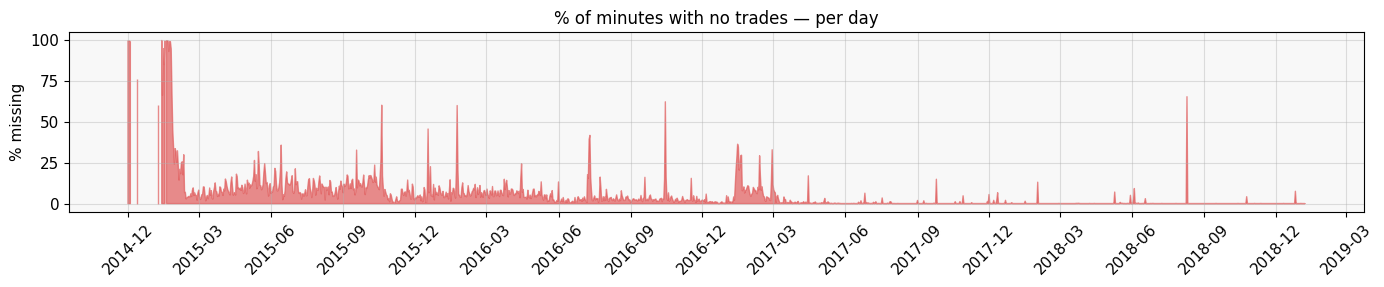


💡 Early in the dataset there will be MORE missing minutes — lower liquidity.
   This is expected for BTC 2014-2016. Recent years should be much denser.


In [ ]:
# --- 2c. Visualise NaN density over time ---
# Convert timestamp for readability
df_raw['datetime'] = pd.to_datetime(df_raw['Timestamp'], unit='s')

# Create a binary is_missing column
df_raw['is_missing'] = df_raw['Close'].isna().astype(int)

# Resample to daily to see the big picture
daily_missing = (
    df_raw.set_index('datetime')['is_missing']
    .resample('D').mean() * 100  # percent of minutes missing per day
)

fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(daily_missing.index, daily_missing.values, alpha=0.7, color='#e05c5c')
ax.set_title('% of minutes with no trades — per day', fontsize=12)
ax.set_ylabel('% missing')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Findings — Gap distribution over time

The chart confirms what we expected — missing minutes are heavily concentrated in
the **2014–2016 period** when BTC trading on Coinbase was sparse and illiquid.
From 2017 onwards the dataset becomes significantly denser with far fewer gaps.

This is the key justification for trimming the dataset to **2017-01-01**.
Keeping the early years would mean forward-filling across very long flat stretches,
which would introduce artificial patterns the model could learn incorrectly.

### Finding the longest consecutive gaps

Knowing the *longest* uninterrupted gap matters more than the average.
A 2-minute gap is harmless to forward-fill. A 38-hour gap produces a long flat line
that looks like a real price signal — the model will learn it as one.

In [ ]:
# --- 2d. Find the longest consecutive gap ---
# A very long gap means the model would be learning a forward-fill artifact

# Identify consecutive NaN runs
is_missing = df_raw['Close'].isna()
groups = is_missing.ne(is_missing.shift()).cumsum()
gap_lengths = is_missing[is_missing].groupby(groups[is_missing]).count()

if len(gap_lengths) > 0:
    top_gaps = gap_lengths.sort_values(ascending=False).head(10)
    print('Top 10 longest consecutive NaN gaps (in minutes):')
    print(top_gaps.values)
    print()
    print(f'Longest gap: {top_gaps.iloc[0]:,} minutes = {top_gaps.iloc[0]/60:.1f} hours')
    print()
    print('Gaps > 60 minutes are significant — filling them with last-known-price')
else:
    print('No NaN gaps found.')

Top 10 longest consecutive NaN gaps (in minutes):
[2303 2142 1358 1326 1222 1050 1023  957  939  901]

Longest gap: 2,303 minutes = 38.4 hours

💡 Gaps > 60 minutes are significant — filling them with last-known-price
   introduces a flat line artifact the model will learn. We should decide
   whether to trim the dataset to a period with denser trading.


### Findings — Consecutive gaps

- The **longest single gap is 38.4 hours** — nearly two full trading days with no activity
- There are **10 gaps longer than 15 hours**, all concentrated in the early dataset
- Forward-filling across a 38-hour gap produces 2,303 identical rows in a row —
  a flat line the model would treat as a genuine price pattern

> This alone is sufficient justification to trim the dataset to 2017-01-01,
> where gaps are short enough that forward-filling is a safe and reasonable strategy.

## Step 3 — Time series regularity

RNNs assume equally-spaced time steps. We already know some 60-second windows
have no trades — but are those rows present in the CSV with NaN values, or are
they missing entirely? If timestamps are skipped, the grid has holes we cannot
see just by looking at NaN counts.

In [ ]:
# --- 3a. Are all 60-second timestamps present? ---
ts = df_raw['Timestamp'].sort_values().reset_index(drop=True)
diffs = ts.diff().dropna()

print('Timestamp diff distribution (seconds):')
print(diffs.value_counts().head(10))
print()

non_60 = diffs[diffs != 60]
print(f'Rows with diff ≠ 60 seconds: {len(non_60):,}')

if len(non_60) > 0:
    print('\nSample irregular gaps:')
    print(non_60.head(10).values)
    print()
    print('💡 Gaps that are exact multiples of 60 (120, 180...) are simply')
    print('   missing rows in the CSV — not timestamp errors. We need to')
    print('   reconstruct the full index before windowing.')

Timestamp diff distribution (seconds):
Timestamp
60.0         2099751
172380.0           1
247500.0           1
101760.0           1
175620.0           1
580200.0           1
1744080.0          1
371940.0           1
108240.0           1
Name: count, dtype: int64

Rows with diff ≠ 60 seconds: 8

Sample irregular gaps:
[ 172380.  247500.  101760.  175620.  580200. 1744080.  371940.  108240.]

💡 Gaps that are exact multiples of 60 (120, 180...) are simply
   missing rows in the CSV — not timestamp errors. We need to
   reconstruct the full index before windowing.


### Findings — Timestamp regularity

- **99.99% of rows are exactly 60 seconds apart** — the time grid is clean
- **8 timestamps have gaps larger than 60 seconds** — these are rows missing entirely
  from the CSV, not just NaN rows
- The largest missing-row gap is **1,744,080 seconds = 20.2 days** — again in the
  early sparse period
- This means the CSV has two types of missing data:
  - **NaN rows** — the timestamp exists but all values are NaN (109,069 rows)
  - **Missing rows** — the timestamp is absent entirely (58,354 rows estimated)

> Before windowing, we must reconstruct the full 60-second DatetimeIndex
> and reindex the dataframe against it. Otherwise those 58,354 rows are
> invisible to the model.

### Reconstructing the full time index

We calculate how many rows *should* exist between the first and last timestamp
at a strict 60-second cadence, then compare against what the CSV actually contains.
The difference tells us exactly how many rows are silently missing.

In [ ]:
# --- 3b. What would a complete time index look like? ---
ts_start = df_raw['Timestamp'].min()
ts_end   = df_raw['Timestamp'].max()

expected_rows = (ts_end - ts_start) // 60 + 1
actual_rows   = len(df_raw)

print(f'Dataset spans: {pd.to_datetime(ts_start, unit="s")} → {pd.to_datetime(ts_end, unit="s")}')
print(f'Expected rows at 60s cadence : {expected_rows:,}')
print(f'Actual rows in CSV           : {actual_rows:,}')
print(f'Missing timestamp rows       : {expected_rows - actual_rows:,}')
print()
print('💡 If expected >> actual, the CSV omits NaN rows entirely.')
print('   We need to reindex to a complete DatetimeIndex before any further work.')

Dataset spans: 2014-12-01 05:33:00 → 2019-01-07 22:06:00
Expected rows at 60s cadence : 2,158,114
Actual rows in CSV           : 2,099,760
Missing timestamp rows       : 58,354

💡 If expected >> actual, the CSV omits NaN rows entirely.
   We need to reindex to a complete DatetimeIndex before any further work.


### Findings — Missing timestamps

- The dataset spans **2014-12-01 to 2019-01-07** — just over 4 years
- A complete 60-second grid over this period requires **2,158,114 rows**
- The CSV contains only **2,099,760 rows** — meaning **58,354 timestamps are absent entirely**
- Combined with the 109,069 NaN rows, the dataset has two distinct missing data problems:

| Type | Count | Treatment |
|------|-------|-----------|
| NaN rows — timestamp present, values missing | 109,069 | Forward-fill |
| Missing rows — timestamp absent from CSV entirely | 58,354 | Reindex then forward-fill |

> In the preprocessing notebook we will first reindex the dataframe to a complete
> 60-second DatetimeIndex, which surfaces the hidden missing rows as NaNs,
> and then forward-fill the entire series in one pass.

### Why forward-fill and not remove?

With tabular data you can drop a row and nothing breaks — the remaining rows are
independent of each other. With a time series that is not true.

Our model learns from **sequences of 1,440 consecutive rows**, each representing
exactly 24 hours. If we remove rows, a window of 1,440 rows no longer means 24 hours
— it means some unknown stretch of time with invisible holes in it. The model would
learn from broken sequences without knowing they are broken.

**Forward-fill is the correct choice because:**
- A minute with no trades genuinely had no new price information — the last known
  price is the accurate price for that window
- It preserves the regular 60-second grid the RNN depends on
- It is fully transparent — we document exactly what we did and why

**The trim to 2017-01-01 is what makes forward-fill safe.**
After trimming, the longest gap drops from 38.4 hours to a few minutes at most.
We are not fabricating two days of flat prices — we are filling occasional
quiet minutes in an otherwise active market, which is a reasonable assumption.

> Removing rows would silently corrupt every sequence window that spans the gap.
> Forward-filling after trimming keeps the data honest.

## Step 4 — Price history

We visualise the full dataset to understand the price range, volume behaviour,
and how closely VWAP tracks the Close price over time.

Plotting 2 million minute-level rows would freeze Colab, so we resample to
daily candles first — 1,800 points is more than enough for a full overview.

Plotting 1,465 daily candles (down from 1,990,691 minute rows)


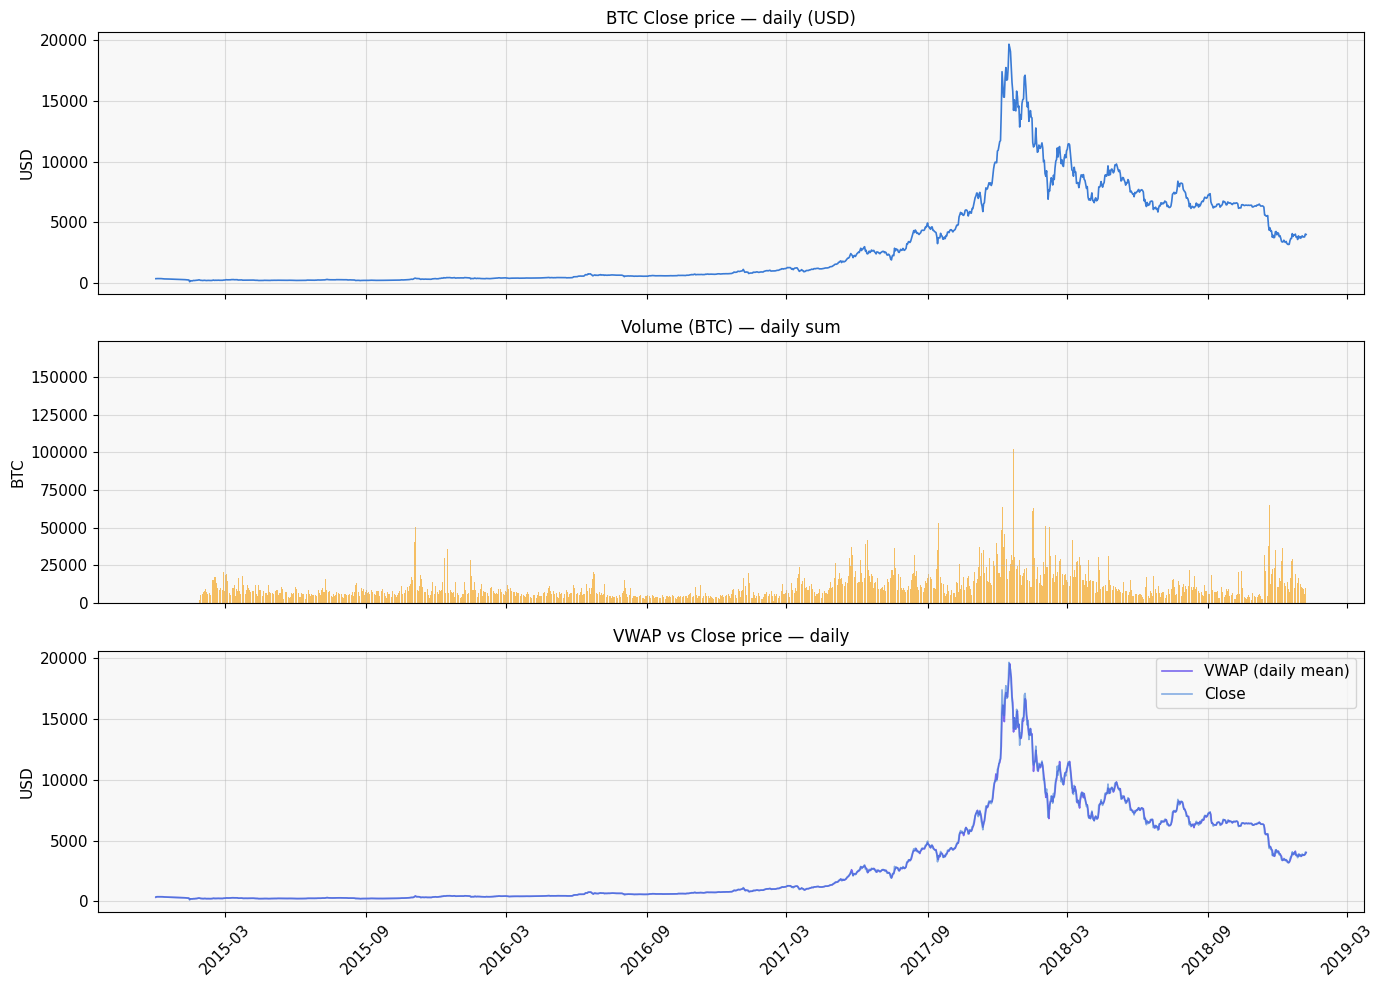

In [ ]:
# --- 4a. Full price history — resampled for performance ---
# 2M minute rows → ~1,800 daily rows. Plenty of detail for an overview.

df_obs = df_raw.dropna(subset=['Close']).copy()
df_obs = df_obs.set_index('datetime')

daily = df_obs.resample('1D').agg({
    'Close':        'last',
    'Volume_(BTC)': 'sum',
    'Weighted_Price': 'mean'
}).dropna()

print(f'Plotting {len(daily):,} daily candles (down from {len(df_obs):,} minute rows)')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Close price
axes[0].plot(daily.index, daily['Close'], lw=1.2, color='#3a7bd5')
axes[0].set_title('BTC Close price — daily (USD)', fontsize=12)
axes[0].set_ylabel('USD')

# Volume BTC (daily sum)
axes[1].bar(daily.index, daily['Volume_(BTC)'],
            width=0.8, color='#f5a623', alpha=0.7)
axes[1].set_title('Volume (BTC) — daily sum', fontsize=12)
axes[1].set_ylabel('BTC')

# VWAP vs Close
axes[2].plot(daily.index, daily['Weighted_Price'],
             lw=1.2, color='#7b68ee', label='VWAP (daily mean)')
axes[2].plot(daily.index, daily['Close'],
             lw=1.2, color='#3a7bd5', alpha=0.6, label='Close')
axes[2].set_title('VWAP vs Close price — daily', fontsize=12)
axes[2].set_ylabel('USD')
axes[2].legend()

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Zooming in — last 30 days

The full history gives us the big picture but hides intraday detail.
We zoom into the final 30 days of the dataset to get a sense of
the price movement at the resolution our model will actually be working with.

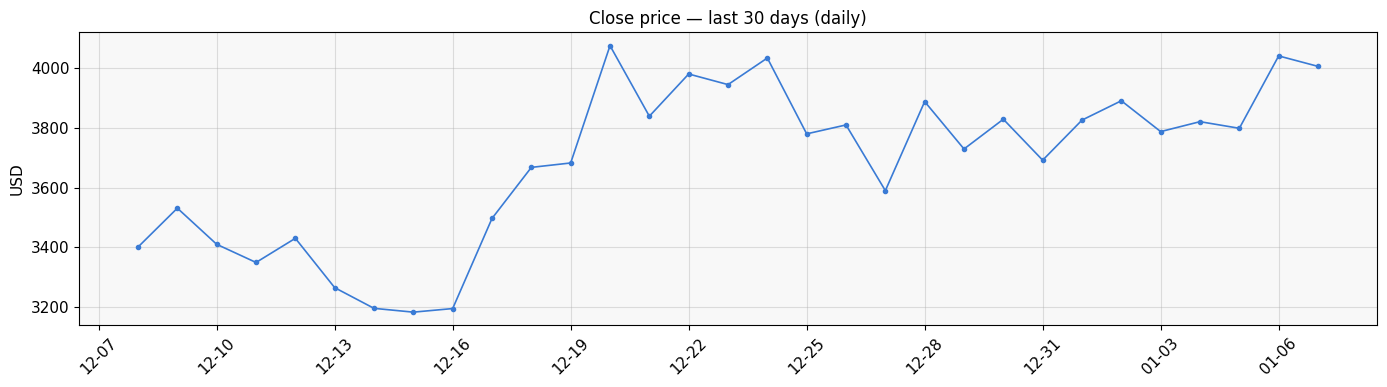

In [ ]:
# --- 4b. Zoom: last 30 days — hourly resolution ---
last_30 = daily[daily.index >= daily.index.max() - pd.Timedelta(days=30)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(last_30.index, last_30['Close'], lw=1.2, color='#3a7bd5', marker='o', ms=3)
ax.set_title('Close price — last 30 days (daily)', fontsize=12)
ax.set_ylabel('USD')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 5 — Feature analysis

Not every column earns its place in the model. Adding redundant or uninformative
features increases model complexity without improving predictions.

We start with a correlation matrix to see which columns are carrying
essentially the same information.

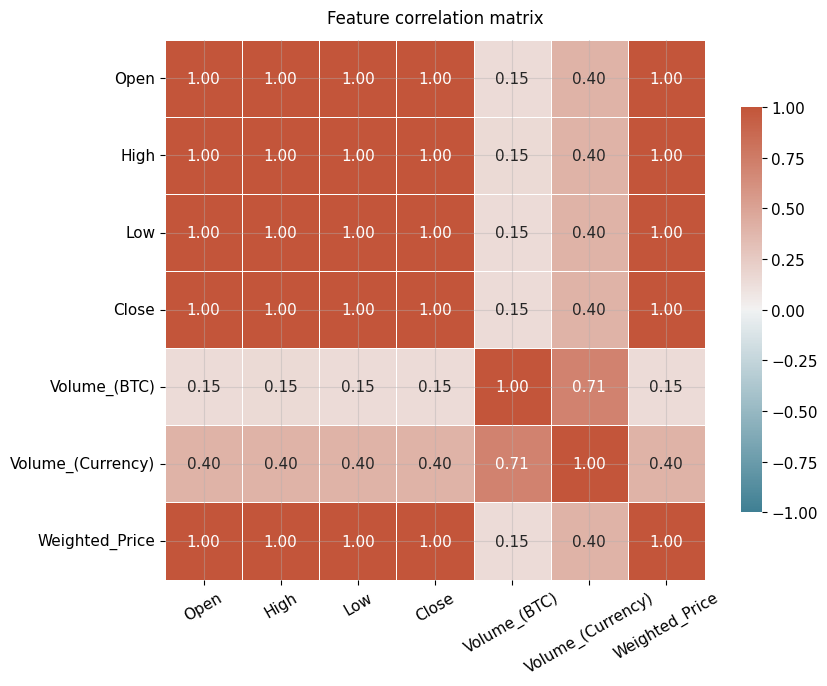

Columns with correlation > 0.99 to Close carry no new information.


In [ ]:
# --- 5a. Correlation matrix (observed rows) ---
feat_cols = ['Open', 'High', 'Low', 'Close', 'Volume_(BTC)', 'Volume_(Currency)', 'Weighted_Price']
corr = df_obs[feat_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'shrink': 0.75}
)
ax.set_title('Feature correlation matrix', fontsize=12, pad=12)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

print('Columns with correlation > 0.99 to Close carry no new information.')

### Findings — Feature correlations

The matrix reveals two distinct groups:

**Price columns — perfectly correlated**
- Open, High, Low, Close and Weighted_Price all correlate at **0.9999 or above**
- They are essentially the same number measured slightly differently within a 60-second window
- Keeping all five would give the model five copies of the same signal

**Volume columns — correlated with each other, not with price**
- Volume_(BTC) and Volume_(Currency) correlate at **0.71** with each other
- Both correlate weakly with price (~0.15 and ~0.40) — volume carries genuinely different information
- Volume_(Currency) is mathematically Volume_(BTC) × Close, so it adds nothing beyond what Volume_(BTC) already provides

**Conclusion**
- From the price group we keep only `Close` — it is our target and sole price input
- From the volume group we keep only `Volume_(BTC)` — it captures trading activity independently
- `Open`, `High`, `Low`, `Weighted_Price` and `Volume_(Currency)` are all dropped

### Quantifying VWAP vs Close

The correlation matrix shows they are nearly identical, but correlation alone
does not tell us the actual dollar difference. We compute the absolute difference
directly to see if VWAP ever carries meaningfully different information.

In [ ]:
# --- 5b. How different is VWAP from Close? ---
diff = (df_obs['Weighted_Price'] - df_obs['Close']).abs()
print('|VWAP - Close| statistics (USD):')
print(diff.describe().round(4))
print()
print('💡 If the mean absolute difference is tiny relative to price,')
print('   VWAP adds almost no information beyond Close.')

|VWAP - Close| statistics (USD):
count    1.990691e+06
mean     1.177600e+00
std      4.786000e+00
min      0.000000e+00
25%      3.400000e-03
50%      3.700000e-02
75%      4.031000e-01
max      8.928903e+02
dtype: float64

💡 If the mean absolute difference is tiny relative to price,
   VWAP adds almost no information beyond Close.


### Findings — VWAP vs Close

- **Median difference is just \$0.04** — for the majority of minutes VWAP and Close are virtually identical
- **75% of minutes have a difference below \$0.40** — negligible at BTC price levels of \$3,000–\$14,000
- The mean of $1.18 and max of \$892 are pulled up by a small number of high-volatility outliers
- At 1-minute resolution, there is simply not enough price movement within a single window
  for VWAP to diverge meaningfully from Close

> `Weighted_Price` is dropped. It adds no information that `Close` does not already carry.

### Open vs Close within a 60-second window

If Open and Close are nearly identical within every 60-second window,
Open carries no information the model cannot already get from Close.
We measure the actual dollar gap between them to confirm.

In [ ]:
# --- 5c. How different is Open from Close within a 60s window? ---
diff_oc = (df_obs['Open'] - df_obs['Close']).abs()
print('|Open - Close| within 60s window (USD):')
print(diff_oc.describe().round(4))
print()
pct_identical = (diff_oc == 0).mean() * 100
print(f'Rows where Open == Close exactly: {pct_identical:.1f}%')

|Open - Close| within 60s window (USD):
count    1.990691e+06
mean     2.167400e+00
std      8.815300e+00
min      0.000000e+00
25%      1.000000e-02
50%      7.000000e-02
75%      7.600000e-01
max      1.773380e+03
dtype: float64

Rows where Open == Close exactly: 23.9%


### Findings — Open vs Close

- **23.9% of rows have Open == Close exactly** — the price did not move at all within that minute
- **Median gap is just \$0.07** — for half of all minutes the entire price range within 60 seconds is seven cents
- **75% of minutes have a gap below \$0.76** — again negligible at BTC price levels
- The mean of \$2.17 and max of \$1,773 are driven by a small number of extreme volatility events

> `Open` is dropped. In a 60-second window it is effectively the same number as `Close`
> for the vast majority of rows, and adding it would give the model a near-duplicate input.

### Volume distribution

Volume passed raw into a neural network causes problems — a handful of extreme
spikes would dominate the scaled range and compress all normal activity into
a tiny slice near zero.

We plot the raw distribution alongside the log1p-transformed version to
confirm that the transform produces a well-behaved input for the model.

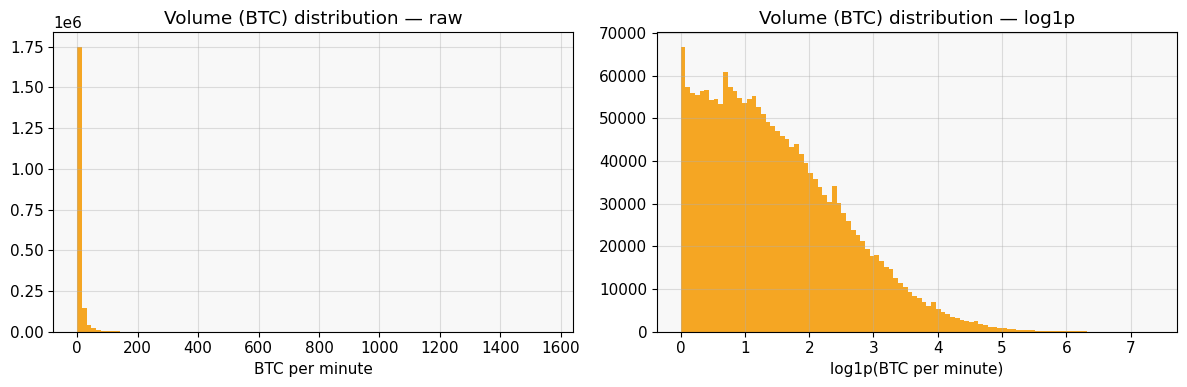


💡 Volume is very right-skewed. Log-transforming before scaling
   prevents extreme-value spikes from dominating the model.


In [ ]:
# --- 5d. Volume distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_obs['Volume_(BTC)'], bins=100, color='#f5a623', edgecolor='none')
axes[0].set_title('Volume (BTC) distribution — raw')
axes[0].set_xlabel('BTC per minute')

# Log-transform shows the spread better
log_vol = np.log1p(df_obs['Volume_(BTC)'])
axes[1].hist(log_vol, bins=100, color='#f5a623', edgecolor='none')
axes[1].set_title('Volume (BTC) distribution — log1p')
axes[1].set_xlabel('log1p(BTC per minute)')

plt.tight_layout()
plt.show()

print()
print('💡 Volume is very right-skewed. Log-transforming before scaling')
print('   prevents extreme-value spikes from dominating the model.')

## Step 6 — Scaling strategy

Neural networks are sensitive to the magnitude of their inputs. Features on
very different scales cause unstable training — the model spends its capacity
adjusting for scale differences rather than learning the underlying pattern.

BTC price grew from \$218 to nearly \$14,000 over our dataset. How we scale
this range has a direct impact on what the model can and cannot learn.
We examine the price history before committing to a strategy.

/tmp/ipykernel_4934/2240852152.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = df_obs['Close'].resample('M').last()


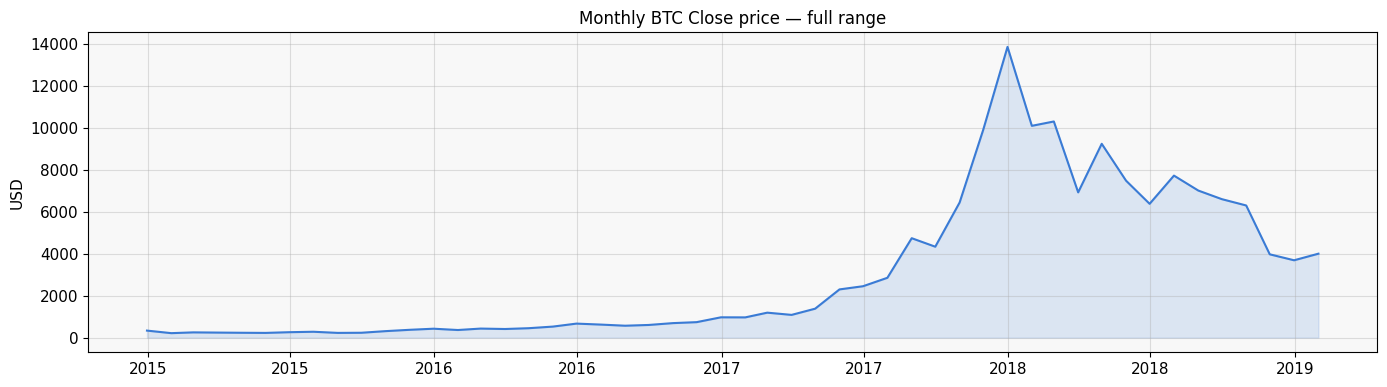

Min Close: $218.45
Max Close: $13,863.13

💡 Two viable approaches:
   A) MinMaxScaler on the TRAINING split only → scale leaks nothing
      but means test values can exceed [0,1] if price breaks training high
   B) Use percent-change (returns) instead of raw price → naturally stationary
      but the model predicts a return, not a price directly


In [ ]:
# --- 6a. Price range over time ---
# BTC went from ~$300 to ~$60k. MinMaxScaler fitted on all data
# would compress early data into a tiny range.
# This is why we need to think carefully.

monthly_close = df_obs['Close'].resample('M').last()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_close.index, monthly_close.values, color='#3a7bd5', lw=1.5)
ax.fill_between(monthly_close.index, monthly_close.values, alpha=0.15, color='#3a7bd5')
ax.set_title('Monthly BTC Close price — full range', fontsize=12)
ax.set_ylabel('USD')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print(f'Min Close: ${monthly_close.min():,.2f}')
print(f'Max Close: ${monthly_close.max():,.2f}')
print()
print('💡 Two viable approaches:')
print('   A) MinMaxScaler on the TRAINING split only → scale leaks nothing')
print('      but means test values can exceed [0,1] if price breaks training high')
print('   B) Use percent-change (returns) instead of raw price → naturally stationary')
print('      but the model predicts a return, not a price directly')

### Returns as an alternative to raw price

One alternative to scaling raw price is to model percent changes (returns) instead.
Returns are naturally stationary — they fluctuate around zero regardless of whether
BTC is at \$300 or \$13,000. We plot the return series and its distribution to
understand what we would be asking the model to predict if we chose this approach.

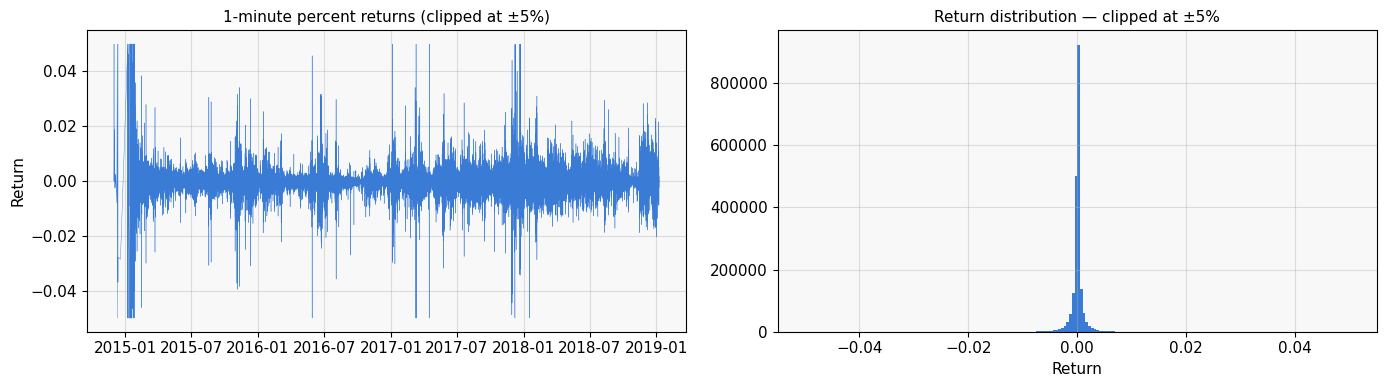

Returns — mean: 0.007971, std: 11.233230
Extreme returns (|r| > 5%): 669 minutes
Extreme returns (|r| > 5%): 0.034% of all minutes


In [ ]:
# --- 6b. Stationarity: returns vs raw price ---
returns = df_obs['Close'].pct_change().dropna()

# Clip extremes for visualisation only — does not affect the data
returns_clipped = returns.clip(-0.05, 0.05)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(returns_clipped.index, returns_clipped.values,
             lw=0.3, color='#3a7bd5')
axes[0].set_title('1-minute percent returns (clipped at ±5%)', fontsize=11)
axes[0].set_ylabel('Return')

axes[1].hist(returns_clipped, bins=200, color='#3a7bd5', edgecolor='none')
axes[1].set_title('Return distribution — clipped at ±5%', fontsize=11)
axes[1].set_xlabel('Return')

plt.tight_layout()
plt.show()

print(f'Returns — mean: {returns.mean():.6f}, std: {returns.std():.6f}')
print(f'Extreme returns (|r| > 5%): {(returns.abs() > 0.05).sum():,} minutes')
print(f'Extreme returns (|r| > 5%): {(returns.abs() > 0.05).mean()*100:.3f}% of all minutes')

## Step 7 — Decision Log

A summary of every decision made in this notebook, justified by the data.


### Decision 1 — Missing data strategy

| Finding | Choice | Reason |
|---------|--------|--------|
| 109,069 rows fully missing (5.19\%) | Forward-fill | Zero-activity minutes — last known price is correct |
| 58,354 timestamps absent from CSV entirely | Reindex then forward-fill | Hidden gaps must be surfaced before filling |
| Longest consecutive gap: 38.4 hours | Trim to 2017-01-01 | A 38-hour flat line is a false pattern, not a real signal |

---

### Decision 2 — Feature selection

| Column | Decision | Reason |
|--------|----------|--------|
| Timestamp | Transform to sin/cos | Encode hour-of-day and day-of-week cyclically |
| Open | Drop | 23.9\% identical to Close; median gap \$0.07 in 60s |
| High | Drop | Correlation with Close: 0.9999 |
| Low | Drop | Correlation with Close: 0.9999 |
| Close | Keep | Prediction target and primary input |
| Volume_(BTC) | Keep — log1p | Independent signal; heavily right-skewed |
| Volume_(Currency) | Drop | Mathematically redundant with Volume_(BTC) × Close |
| Weighted_Price | Drop | Median difference from Close is $0.04 |

**Final feature set:** `Close`, `Volume_(BTC)` (log1p), `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`

---

### Decision 3 — Scaling strategy

**Choice: MinMaxScaler fitted on training split only**

- Price range is $218.45 → $13,863.13 — a 63× spread
- Scaler fitted only on training data to prevent leakage into val/test
- Saved as `scaler.pkl` to inverse-transform predictions back to USD
- `Volume_(BTC)` log1p transformed before scaling
- Cyclical sin/cos features already in [-1, 1] — no scaling issues
- Returns approach rejected — adds reconstruction complexity and the
  std of 11.23 indicates outliers requiring additional treatment

---

### Decision 4 — Time split

**Boundaries**

| Split | Date range | Approx share |
|-------|-----------|-------------|
| Train | 2017-01-01 → 2018-07-01 | 80% |
| Validation | 2018-07-01 → 2018-10-15 | 15% |
| Test | 2018-10-15 → 2019-01-07 | 5% |

**Windowing**

| Parameter | Value | Reason |
|-----------|-------|--------|
| Window size | 1,440 rows | 24 hours of lookback at 1-min resolution |
| Horizon | 60 rows ahead | Predict close price at end of next hour |
| Sample shape | X: (1440, 6) → y: (1,) | 6 features, 1 target |
| Stride | 1 minute | Maximum use of available data |

> Split is strictly chronological — random shuffling would leak future prices
> into the training set and produce artificially high accuracy.